## Setting Up the Libs and Overthrust Configurations

In [1]:
###### from __future__ import print_function
import time
import torch
import torch.nn as nn
import numpy as np
import scipy.ndimage
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import deepwave
import os
from timeit import default_timer as timer
import scipy.io as spio
import math
import numpy as np
from utils.utils import *
from torch import optim
from IPython.core.debugger import set_trace 
import random
torch.manual_seed(0)
random.seed(0)

####################################################
####   MAIN PARAMETERS FOR FORWARD MODELING         ####
####################################################

peak_freq = 10                    # central frequency
peak_source_time = 1 / peak_freq  # the time (in secs) of the peak amplitude
dx        = 30.0                  # step interval along x/z direction
dx1        = 30.0                  # step interval along y/z direction

dt        = 0.003                 # time interval (e.g., 3ms)
num_dims  = 2                     # dimension of velocity model
nz        = 94                   # model shape of z dimension (depth) Overthrust
ny        = 400                   # model shape of y dimension Overthrust
vmodel_dim = np.array([nz, ny])

total_t   = 6.                      # totle sampling time (unit: s)
nt        = int(total_t / dt)       # number of time sampling points
num_shots = 30                      # nunmber of shots
num_sources_per_shot = 1            # number of sources per shot
num_receivers_per_shot = ny        # number of receivers per shot
source_spacing = np.floor(dx * ny / (num_shots+1))                         # space intervel between neigbouring sources
receiver_spacing = np.floor(dx1 * ny / (num_receivers_per_shot +1))         # space intervel between neigbouring receivers
source_depth = 0                # the index depth of sources, default is 0
receiver_depth = 0              # the index depths of receivers, default is 0
order          = 8              # precision order of finite difference in space domain
pml_width  = [0,10,10,10,0,0]   # pml padding width for boundary (0 for free surface and 10 for absorbing boundary)

fwi_lr            = 60        # learning rate for updating the model.
fwi_batch         =   30      # number of batches for FWI.
fwi_num_epochs    = 400       # number of FWI iteration.
sim_lr            = 1*1e-7    # learning rate for Soamese network.
survey_pad = None
savepoch = 50                 # Saving models each 50 FWI iterations


/home/sadalyom/.conda/envs/FWIGAN/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##   Check Cuda Device 


In [2]:
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True

cuda_available = torch.cuda.is_available()
device = torch.device("cuda" if cuda_available else "cpu")
device 

device(type='cuda')

## Creating Data Pathes

In [3]:
 
data_path = 'data/over_94_400.bin'
initfile = 'data/over_initmodel_FLAT.mat'
initsafile = 'data/over_initsource.mat'
fwi_result = 'results/overthrust/'

fwi_result = 'results/Overthrust_SiameseFit_Constant/'

# Check if the directory exists
if not os.path.exists(fwi_result):
    # Create the directory
    os.makedirs(fwi_result)
    print(f"Directory '{fwi_result}' created.")
else:
    print(f"Directory '{fwi_result}' already exists.")
    
    
# Loading the true model
model_true = loadtruemodel(data_path, num_dims, vmodel_dim).to(device)
model, model_init = loadinitmodel(initfile,device)
# The model will be updated during FWI
 
model_init[:,:] = 3000
model[:,:] = 3000


model = torch.nn.Parameter(model)
# Creating source and reciver locations
x_s, x_r = createSR(num_shots, num_sources_per_shot, num_receivers_per_shot, num_dims, source_spacing, receiver_spacing,source_depth,receiver_depth)
x_s, x_r = x_s.to(device), x_r.to(device)
# Source Amplitude
source_amplitudes_init, source_amplitudes_true = loadinitsource(initsafile,device)
source = source_amplitudes_init.repeat(1,num_shots, num_sources_per_shot)
# receiver Amplitude
receiver_amplitudes = createdata(model_true,dx,source, \
                                x_s,x_r,dt,pml_width,order, \
                                 survey_pad,device).to(device)
receiver_amplitudes_true = receiver_amplitudes
rcv_amps_true = receiver_amplitudes_true.clone()

Directory 'results/Overthrust_SiameseFit_Constant/' already exists.


In [4]:
rcv_amps_true.shape

torch.Size([2000, 30, 400])

## Plotting the inital and true model


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


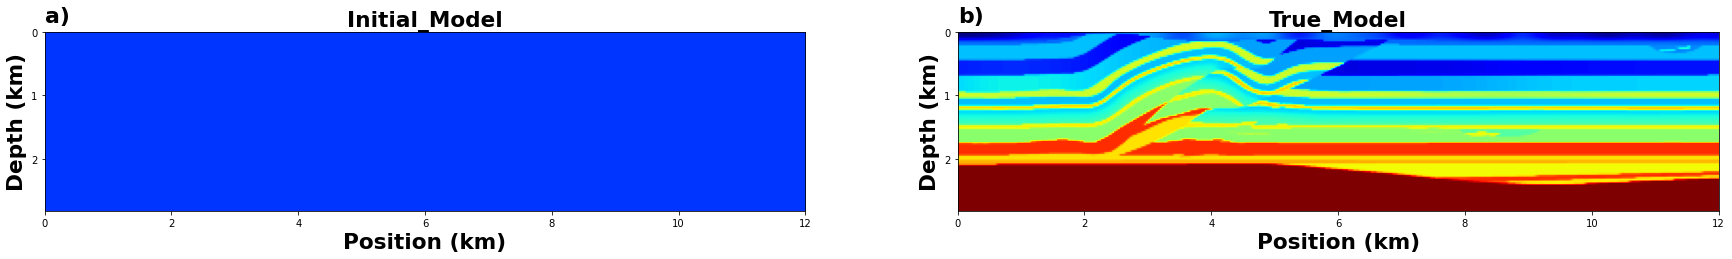

In [5]:
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : 18}

y = np.array([0, 1, 2, 3])
box_min = 2360
box_max = 6000

f, ax = plt.subplots(1,2,figsize=(30, 13))
plt.rc('font', **font)


im = ax[0].imshow(model_init, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, model_init.shape[1] * dx / 1000, model_init.shape[0] * dx / 1000, 0])
ax[0].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[0].set_title('Initial_Model',fontsize='large', fontweight='bold')
ax[0].text(0, -0.15, 'a)', fontsize = 22) 
ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].set_yticks(np.arange(y.min(), y.max(), 1)) 

model1 = model_true.detach().cpu().numpy()
im = ax[1].imshow(model1, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, model1.shape[1] * dx / 1000, model1.shape[0] * dx / 1000, 0])
ax[1].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[1].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[1].set_title('True_Model',fontsize='large', fontweight='bold')
ax[1].text(0, -0.15, 'b)', fontsize = 22) 
ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].set_yticks(np.arange(y.min(), y.max(), 1)) 


plt.show()

## Setting Up the Siamese and Optimizers

In [6]:
from torchsummary import summary
from Model.Module22xP_1 import *
import  torch


#Learning Schedule
def lr_lambda(epoch):
    return 10

#Learning Schedule
def lr_lambdaM(epoch):
    return 1/4

### optimizer for the velocity model
optimizer = optim.Adam([{'params': model, 'lr':fwi_lr, 'betas':(0.5, 0.99), 'eps':1e-22,
                          'weight_decay':0}])

#Best
#leak_value = 0.0001
leak_value = 1
D1 = 16
netD = SiameseNetwork(D1)
### init the hyper-parameters of netD ###
netD = netD.apply(lambda m: weights_init(m, leak_value))
netD = netD.to(device)


# Optimizer for Siamese network.
optim_s = optim.Adam(netD.parameters(),lr=sim_lr,betas=(0.5, 0.9), \
                    eps=1e-8, weight_decay=0)

scheduler = torch.optim.lr_scheduler.MultiplicativeLR(optim_s, lr_lambda=lr_lambda)
schedulerM = torch.optim.lr_scheduler.MultiplicativeLR(optimizer, lr_lambda=lr_lambdaM)

"""Compute number of parameters"""
s  = sum(np.prod(list(p.size())) for p in netD.parameters())
print ('Number of netD params: %d' % s)

summary(netD,[(1,nt,num_receivers_per_shot)])


############## Init  ################# 
SNR = 0.0
SSIM = 0.0
Loss = 0.0
ERROR = 0.0




Number of netD params: 100705
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1        [-1, 16, 2000, 400]             160
         LeakyReLU-2        [-1, 16, 2000, 400]               0
            Conv2d-3        [-1, 32, 2000, 400]             320
         LeakyReLU-4        [-1, 32, 2000, 400]               0
            Conv2d-5        [-1, 64, 2000, 400]             640
         LeakyReLU-6        [-1, 64, 2000, 400]               0
            Conv2d-7       [-1, 128, 2000, 400]           1,280
         LeakyReLU-8       [-1, 128, 2000, 400]               0
            Conv2d-9        [-1, 16, 2000, 400]             160
        LeakyReLU-10        [-1, 16, 2000, 400]               0
        MaxPool2d-11        [-1, 16, 1000, 200]               0
        MaxPool2d-12        [-1, 16, 1000, 200]               0
           Conv2d-13        [-1, 32, 1000, 200]           4,640
        L

In [7]:
def plot():
    f, ax = plt.subplots(3,1,figsize=(40, 20))
    plt.rc('font', **font)

    # True Model
    modeltrue = model1
    im = ax[0].imshow(modeltrue, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, modeltrue.shape[1] * dx / 1000, modeltrue.shape[0] * dx / 1000, 0])

    #ax[0].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
    ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
    ax[0].set_title('True_Model',fontsize='large', fontweight='bold')
    ax[0].text(0, -0.15, 'a)', fontsize = 22) 
    ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[0].set_yticks(np.arange(y.min(), y.max(), 1)) 

    # Initial Model
    init_V = model_init
    im = ax[1].imshow(init_V, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, init_V.shape[1] * dx / 1000, init_V.shape[0] * dx / 1000, 0])
    #ax[1].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
    ax[1].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
    ax[1].set_title('Initial_Model',fontsize='large', fontweight='bold')
    ax[1].text(0, -0.15, 'b)', fontsize = 22) 
    ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[1].set_yticks(np.arange(y.min(), y.max(), 1)) 

    # Siamese Model
    im = ax[2].imshow(model.detach().cpu().numpy(), cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, model.shape[1] * dx / 1000, model.shape[0] * dx / 1000, 0])
    ax[2].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
    ax[2].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
    ax[2].set_title('SiameseFit',fontsize='large', fontweight='bold')
    ax[2].text(0, -0.15, 'c)', fontsize = 22) 
    ax[2].xaxis.set_major_locator(MaxNLocator(integer=True))
    ax[2].set_yticks(np.arange(y.min(), y.max(), 1)) 


    cbar_ax = f.add_axes([0.8, 0.1, 0.01, 0.8])
    f.colorbar(im, fraction=0.005, pad=0.04,cax=cbar_ax)
    cbar_ax.set_ylabel('Velocity (m/s)',fontsize='large', fontweight='bold')

    plt.show()


## Main SiameseFit


findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


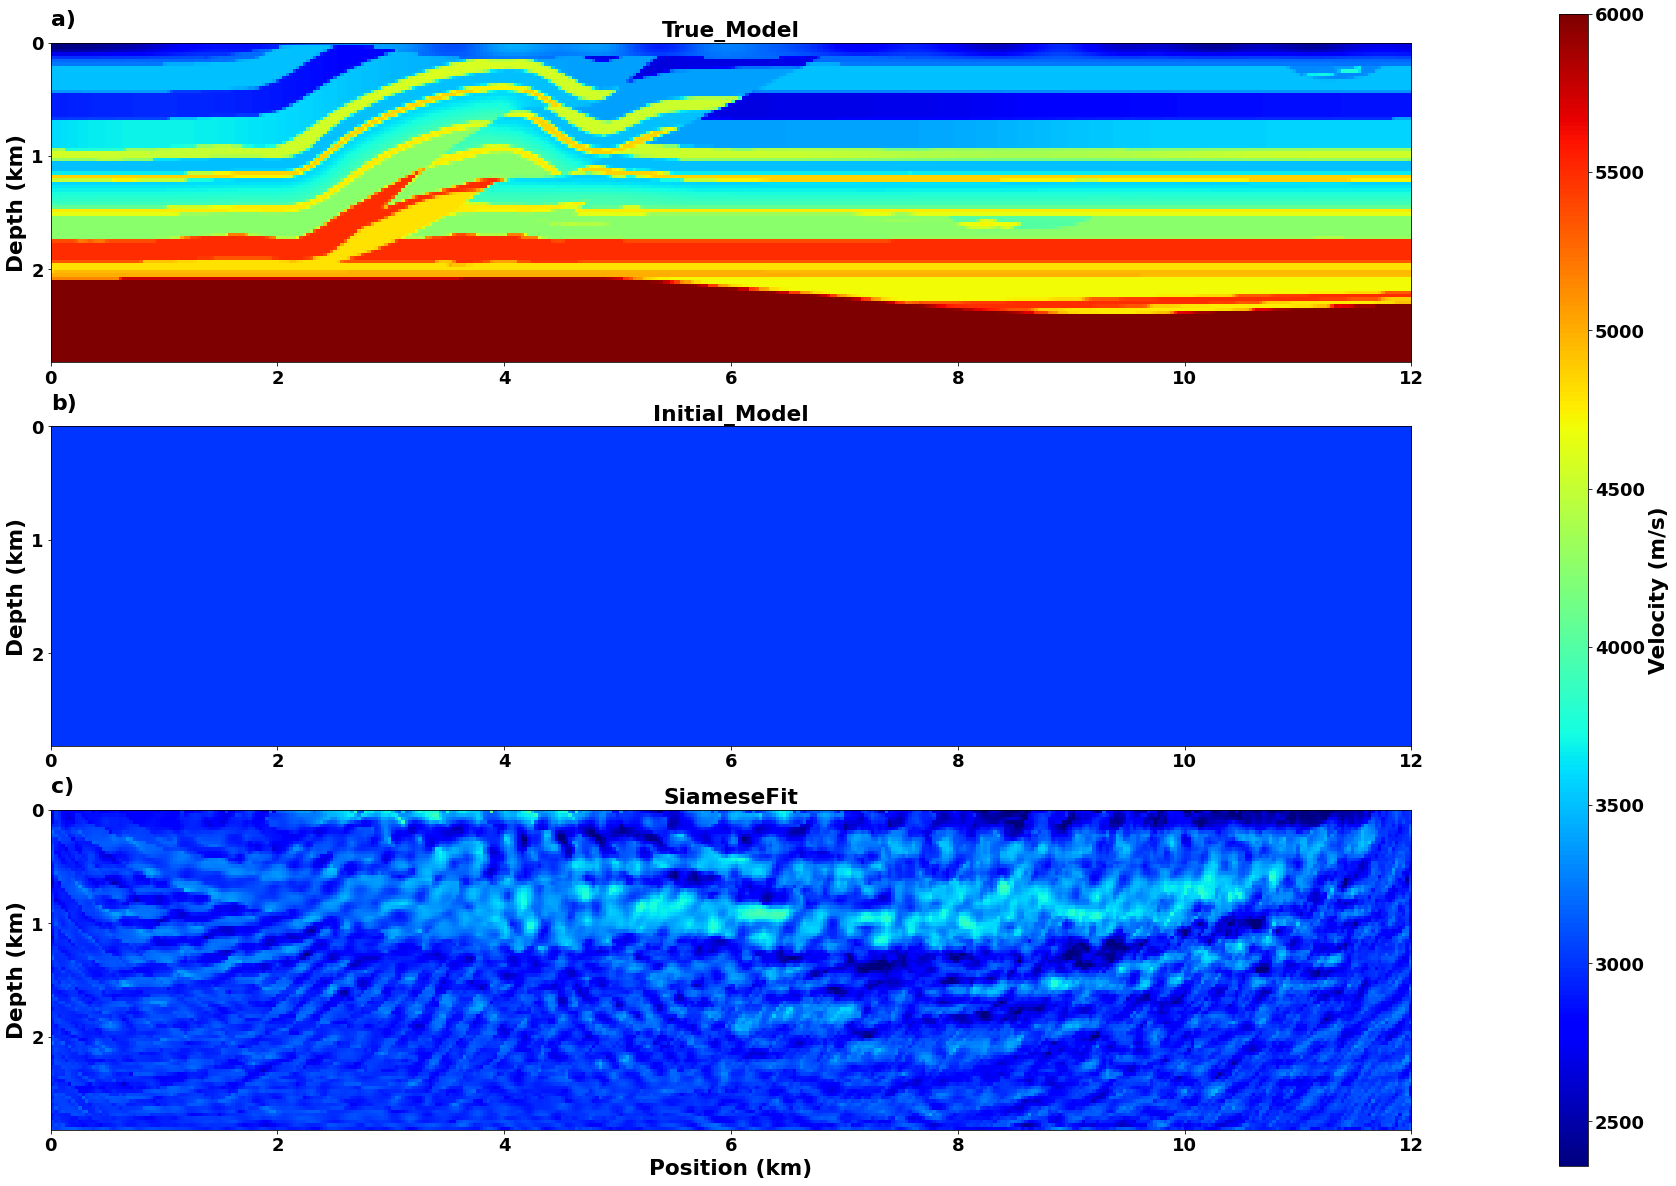

Epoch: 1 Loss:  0.0005686042956464613 lr_DL: 1e-07 lr_vel: 60 SNR: 8.035515903801345 SSIM: 0.10967324
Epoch: 2 Loss:  0.00048142164305318145 lr_DL: 1e-07 lr_vel: 60 SNR: 8.082307297812385 SSIM: 0.11717745
Epoch: 3 Loss:  0.00043254826062669356 lr_DL: 1e-07 lr_vel: 60 SNR: 8.140381907760709 SSIM: 0.12893794
Epoch: 4 Loss:  0.00040480563475284723 lr_DL: 1e-07 lr_vel: 60 SNR: 8.171999377023658 SSIM: 0.13827148
Epoch: 5 Loss:  0.00039787315666520346 lr_DL: 1e-07 lr_vel: 60 SNR: 8.20372813500409 SSIM: 0.15869865
Epoch: 6 Loss:  0.000372729418935099 lr_DL: 1e-07 lr_vel: 60 SNR: 8.20834561815675 SSIM: 0.16140752
Epoch: 7 Loss:  0.0003677587422619884 lr_DL: 1e-07 lr_vel: 60 SNR: 8.237164538850369 SSIM: 0.15692991
Epoch: 8 Loss:  0.00032589266726669545 lr_DL: 1e-07 lr_vel: 60 SNR: 8.292247654054682 SSIM: 0.16056122
Epoch: 9 Loss:  0.00033694955442721645 lr_DL: 1e-07 lr_vel: 60 SNR: 8.346021330842188 SSIM: 0.14917614
Epoch: 10 Loss:  0.0003284664247379017 lr_DL: 1e-07 lr_vel: 60 SNR: 8.385195379

Epoch: 81 Loss:  0.00015744087674344578 lr_DL: 1e-07 lr_vel: 60 SNR: 10.093171521063983 SSIM: 0.1794909
Epoch: 82 Loss:  0.0001625589012595204 lr_DL: 1e-07 lr_vel: 60 SNR: 10.112246734102424 SSIM: 0.17444727
Epoch: 83 Loss:  0.0001470383637448928 lr_DL: 1e-07 lr_vel: 60 SNR: 10.149417401282273 SSIM: 0.17301741
Epoch: 84 Loss:  0.00014926440538450456 lr_DL: 1e-07 lr_vel: 60 SNR: 10.149005781820597 SSIM: 0.17722596
Epoch: 85 Loss:  0.00014019281613097216 lr_DL: 1e-07 lr_vel: 60 SNR: 10.185588754604392 SSIM: 0.17382716
Epoch: 86 Loss:  0.00014036069260328076 lr_DL: 1e-07 lr_vel: 60 SNR: 10.168922999124216 SSIM: 0.17427163
Epoch: 87 Loss:  0.0001428356728865765 lr_DL: 1e-07 lr_vel: 60 SNR: 10.222825042647681 SSIM: 0.18020281
Epoch: 88 Loss:  0.00014526179681221643 lr_DL: 1e-07 lr_vel: 60 SNR: 10.208887680901936 SSIM: 0.17257817
Epoch: 89 Loss:  0.0001545330630809379 lr_DL: 1e-07 lr_vel: 60 SNR: 10.29260195570306 SSIM: 0.18035868
Epoch: 90 Loss:  0.00013783279500785285 lr_DL: 1e-07 lr_vel: 

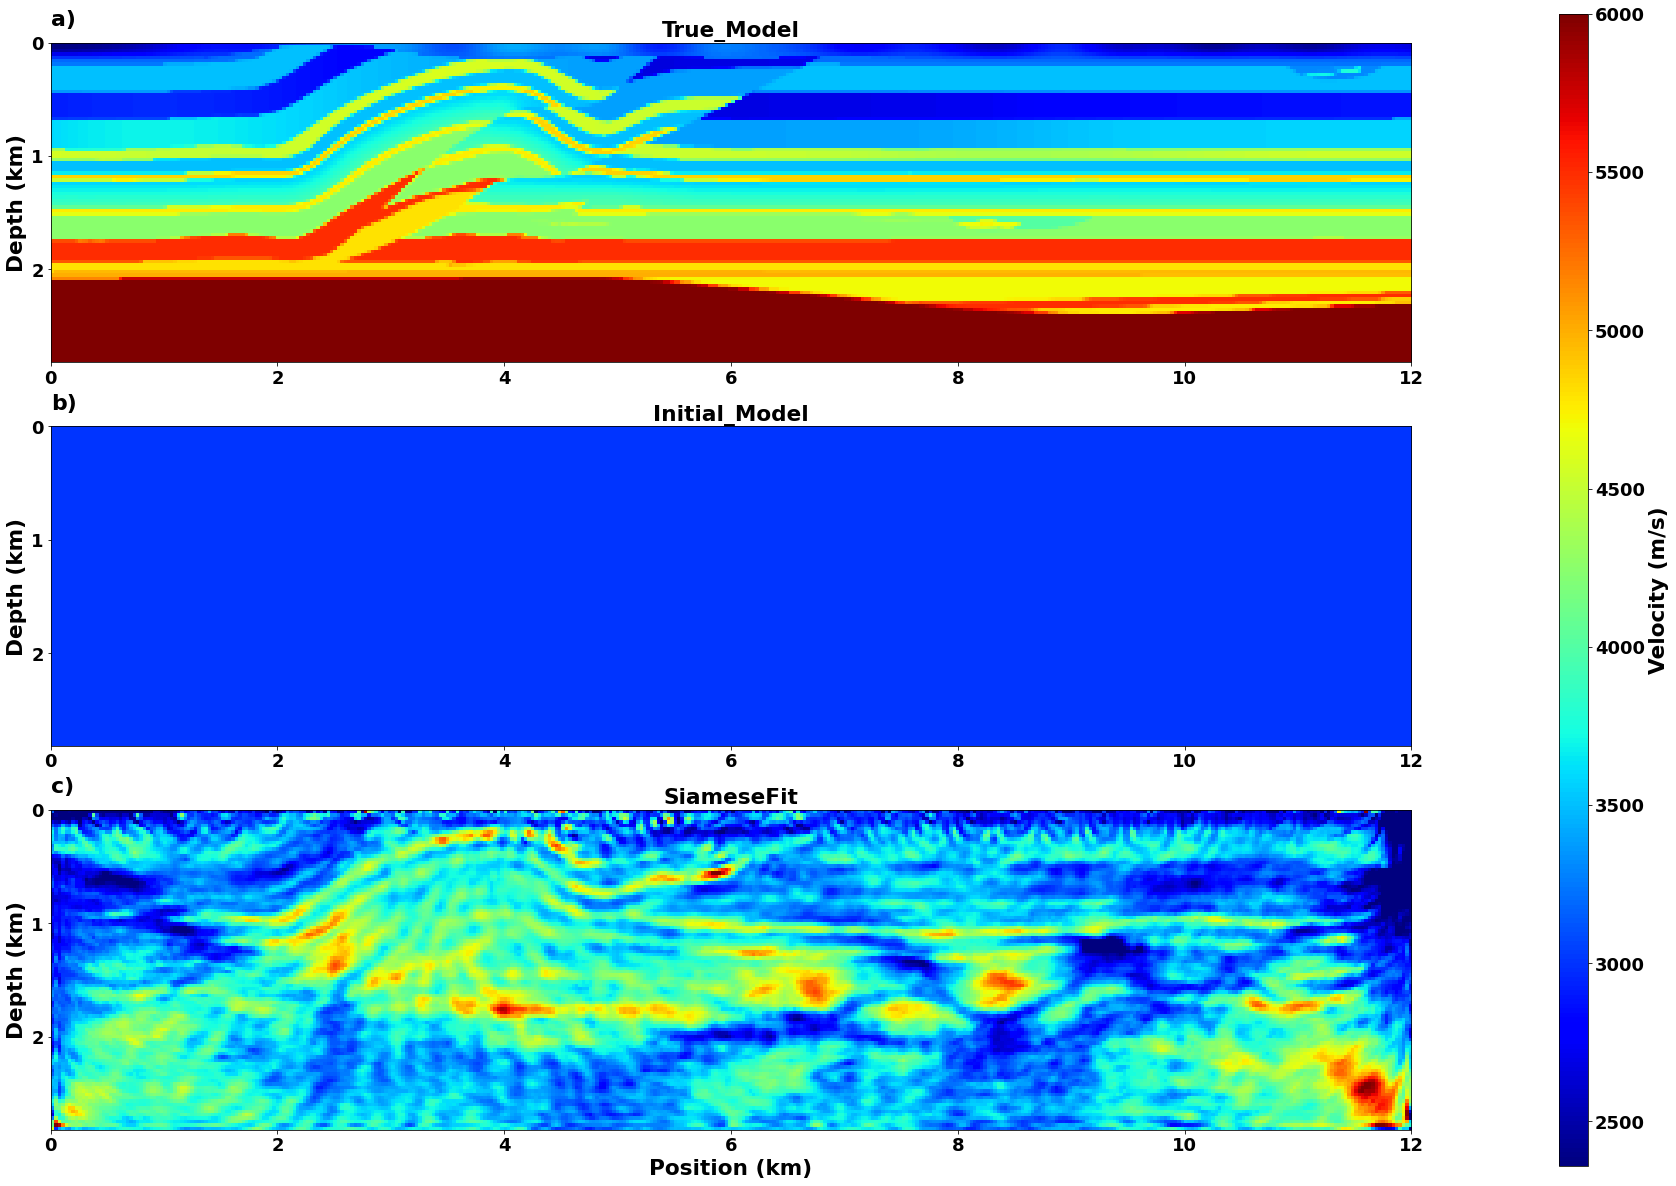

Epoch: 101 Loss:  0.00012999957034480757 lr_DL: 1e-07 lr_vel: 60 SNR: 10.588600965932178 SSIM: 0.21601102
Epoch: 102 Loss:  0.00013635879683230692 lr_DL: 1e-07 lr_vel: 60 SNR: 10.615486307836841 SSIM: 0.21471871
Epoch: 103 Loss:  0.00012502776565573488 lr_DL: 1e-07 lr_vel: 60 SNR: 10.63807776541655 SSIM: 0.2200272
Epoch: 104 Loss:  0.00012630746108091746 lr_DL: 1e-07 lr_vel: 60 SNR: 10.702567423425318 SSIM: 0.22022949
Epoch: 105 Loss:  0.00012329839955782518 lr_DL: 1e-07 lr_vel: 60 SNR: 10.719280106350006 SSIM: 0.22675179
Epoch: 106 Loss:  0.00012789520090639901 lr_DL: 1e-07 lr_vel: 60 SNR: 10.776504561944225 SSIM: 0.23082873
Epoch: 107 Loss:  0.00012893495052897683 lr_DL: 1e-07 lr_vel: 60 SNR: 10.776150708827892 SSIM: 0.23726763
Epoch: 108 Loss:  0.00013346408498667492 lr_DL: 1e-07 lr_vel: 60 SNR: 10.841766117985415 SSIM: 0.23762941
Epoch: 109 Loss:  0.00012456169715733268 lr_DL: 1e-07 lr_vel: 60 SNR: 10.86436998573985 SSIM: 0.24550833
Epoch: 110 Loss:  0.0001262233199668117 lr_DL: 1e

Epoch: 179 Loss:  9.15020009415457e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 13.929702602805172 SSIM: 0.3853943
Epoch: 180 Loss:  9.780850632523652e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.02931436854557 SSIM: 0.3818946
Epoch: 181 Loss:  8.404502089736828e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.082432473901278 SSIM: 0.39007354
Epoch: 182 Loss:  8.707363425249544e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.11844913271495 SSIM: 0.38321605
Epoch: 183 Loss:  8.93538282980444e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.211112104738588 SSIM: 0.39132416
Epoch: 184 Loss:  9.106552509668594e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.29964678956972 SSIM: 0.38804385
Epoch: 185 Loss:  9.387488086455656e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.321830476666406 SSIM: 0.39327294
Epoch: 186 Loss:  9.295951919436144e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.398734433144309 SSIM: 0.39915264
Epoch: 187 Loss:  7.90656648556857e-05 lr_DL: 1e-07 lr_vel: 60 SNR: 14.467087004509446 SSIM: 0.40467128
Epoch: 188 Loss:  8.392628333240282e-05 lr_DL: 1e-07 lr_vel: 60

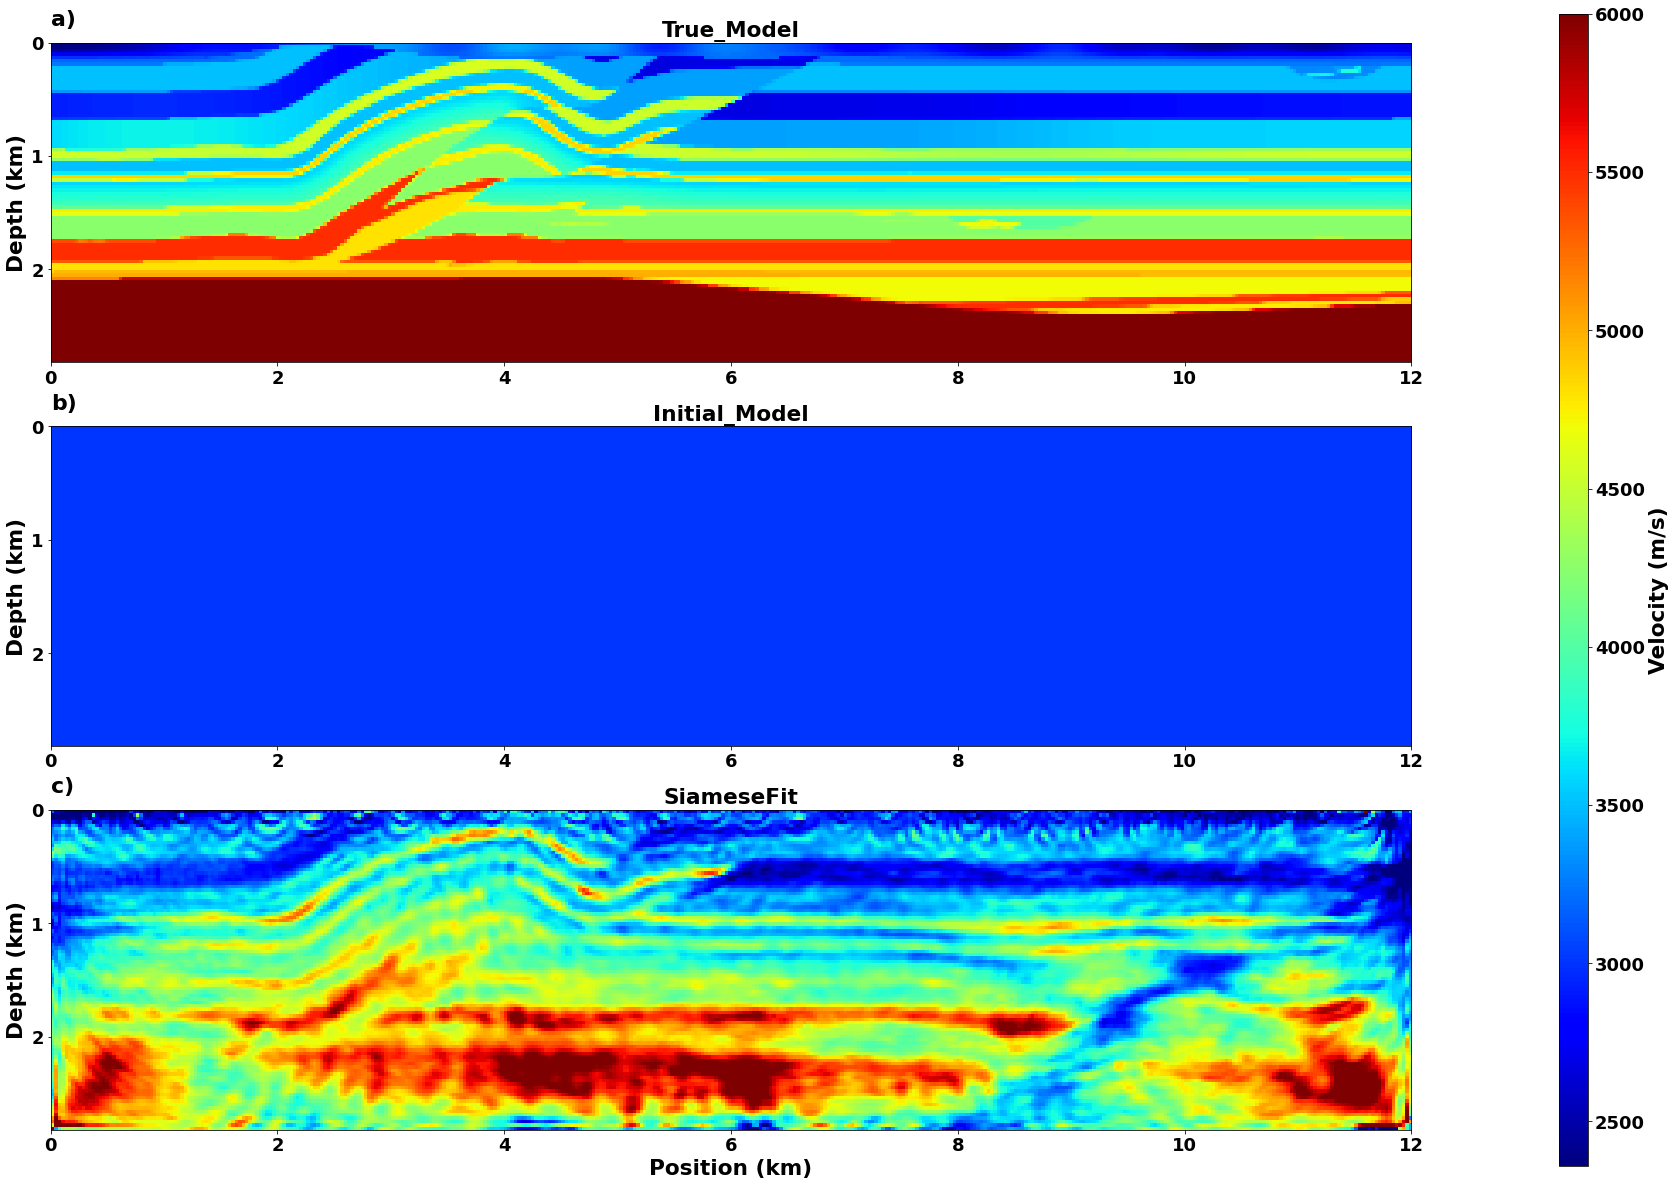

Epoch: 201 Loss:  7.704395441881692e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.437714831542715 SSIM: 0.43975976
Epoch: 202 Loss:  7.365423237691479e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.49754815961011 SSIM: 0.4638205
Epoch: 203 Loss:  4.8252367802585167e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.549385153416601 SSIM: 0.47392204
Epoch: 204 Loss:  4.12414826011324e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.600473629477676 SSIM: 0.4805871
Epoch: 205 Loss:  3.888732450529157e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.647627553358399 SSIM: 0.48617545
Epoch: 206 Loss:  3.9375330622230346e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.696508015149156 SSIM: 0.4900677
Epoch: 207 Loss:  4.0065770735964176e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.740739785196896 SSIM: 0.49481997
Epoch: 208 Loss:  4.027915019833017e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.780988836822104 SSIM: 0.49690259
Epoch: 209 Loss:  3.9992524216359014e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 15.819378731041203 SSIM: 0.5013341
Epoch: 210 Loss:  3.904482540140937e-05

Epoch: 279 Loss:  2.71308272810226e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.311459248460267 SSIM: 0.5701303
Epoch: 280 Loss:  2.766644004926396e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.323698227319152 SSIM: 0.56961155
Epoch: 281 Loss:  2.699498321211043e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.340135154618167 SSIM: 0.5710714
Epoch: 282 Loss:  2.7562830958534808e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.352545844793823 SSIM: 0.5705601
Epoch: 283 Loss:  2.689636924818236e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.369376948413628 SSIM: 0.5720411
Epoch: 284 Loss:  2.749692230281653e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.3814290321128 SSIM: 0.5715536
Epoch: 285 Loss:  2.6753223088841575e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.39837871688917 SSIM: 0.57304996
Epoch: 286 Loss:  2.739599658525549e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.410829932275128 SSIM: 0.5725896
Epoch: 287 Loss:  2.6548848109086975e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.43007797186635 SSIM: 0.57406294
Epoch: 288 Loss:  2.7280716919146166e-05 lr_D

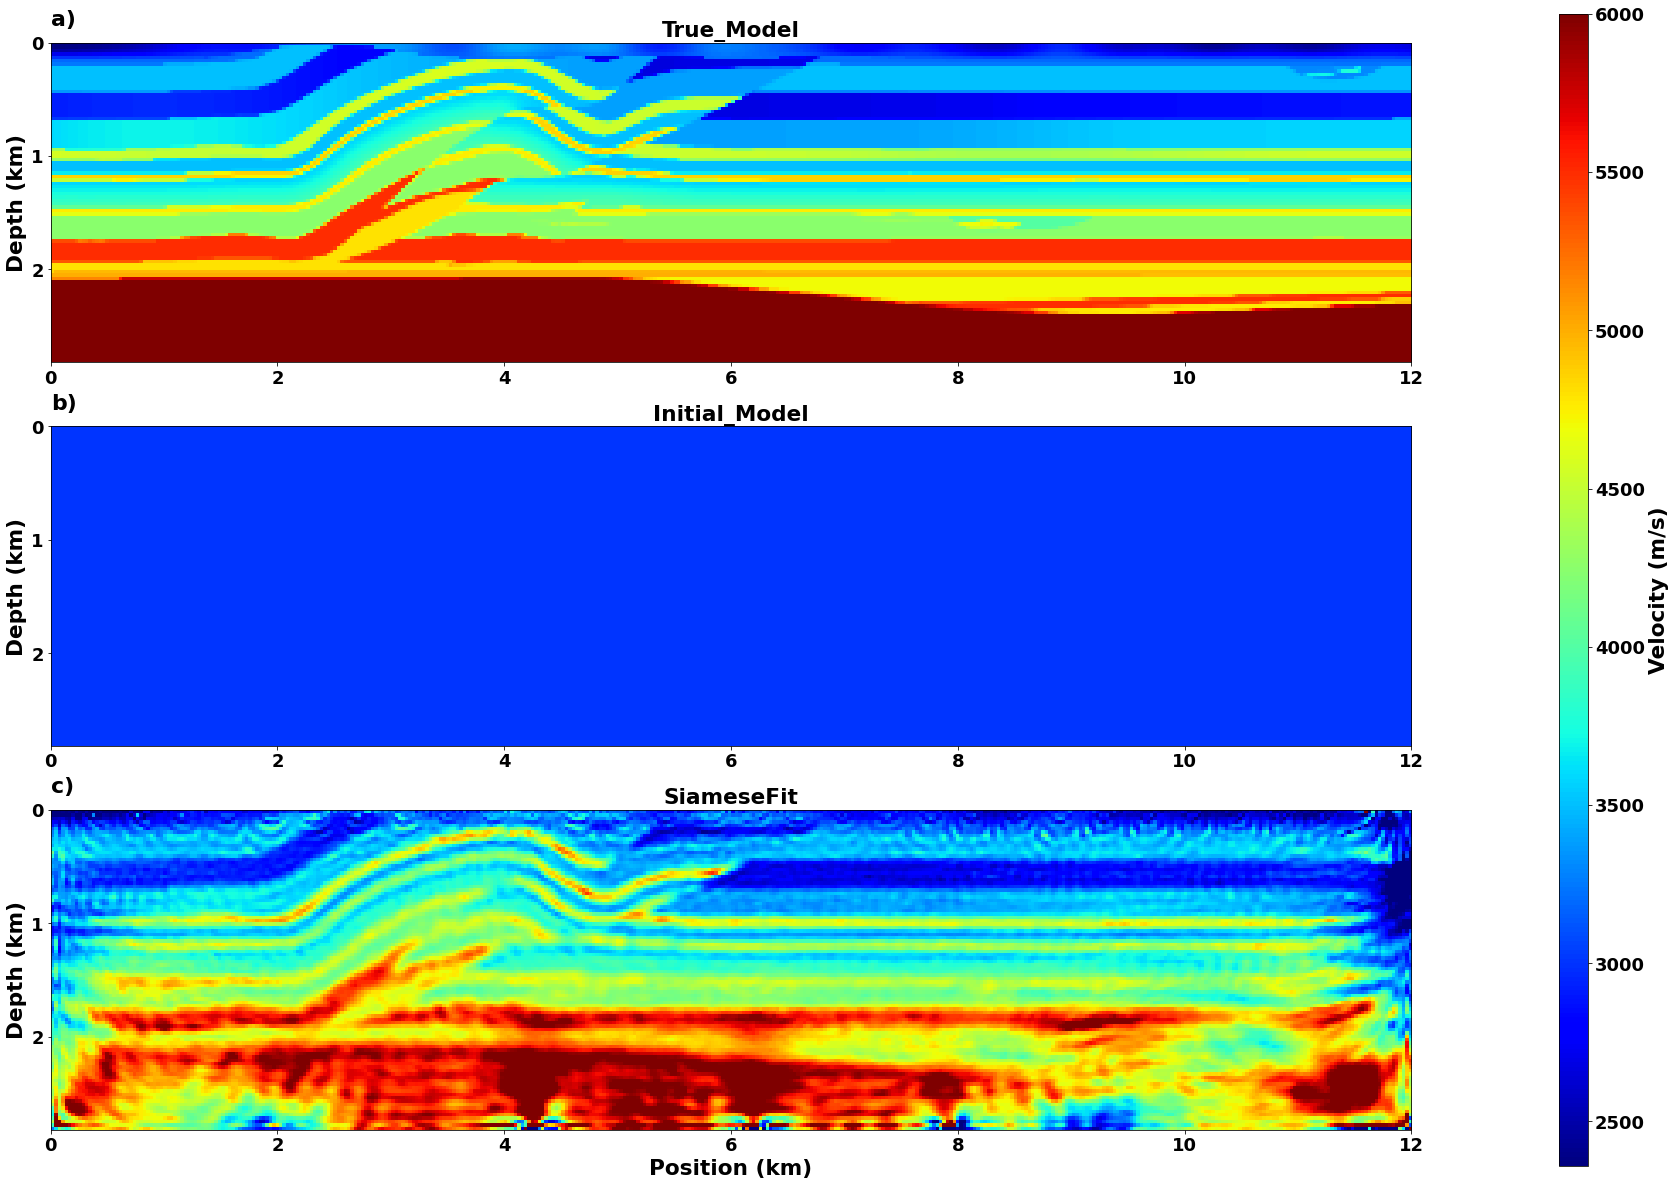

Epoch: 301 Loss:  2.551791991815359e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.641896233981807 SSIM: 0.58137065
Epoch: 302 Loss:  2.6490088021091652e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.655249261196907 SSIM: 0.5805026
Epoch: 303 Loss:  2.5430191393146136e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.67039680761554 SSIM: 0.5822853
Epoch: 304 Loss:  2.640216080180835e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.68336156816189 SSIM: 0.5812968
Epoch: 305 Loss:  2.5360913423355668e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.697811512956477 SSIM: 0.5832117
Epoch: 306 Loss:  2.6245357791291705e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.710733919354368 SSIM: 0.5820132
Epoch: 307 Loss:  2.5324530421736807e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.726039446191916 SSIM: 0.58389294
Epoch: 308 Loss:  2.6072308901348152e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.737884566058757 SSIM: 0.5828907
Epoch: 309 Loss:  2.5270675602466024e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 17.752361970399548 SSIM: 0.58460087
Epoch: 310 Loss:  2.5783483518656188e-

Epoch: 378 Loss:  2.4072492002839378e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.118105723065426 SSIM: 0.5927302
Epoch: 379 Loss:  2.29398422864809e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.1126615284349 SSIM: 0.59367627
Epoch: 380 Loss:  2.401106291169223e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.113723851981526 SSIM: 0.5926625
Epoch: 381 Loss:  2.2898908234007347e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.10788718026011 SSIM: 0.59362763
Epoch: 382 Loss:  2.397229000052903e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.108615697182696 SSIM: 0.5925974
Epoch: 383 Loss:  2.2865536387447112e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.102369445510952 SSIM: 0.59361506
Epoch: 384 Loss:  2.39342634207181e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.102237177577173 SSIM: 0.59252864
Epoch: 385 Loss:  2.2821322575813006e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.095737075709813 SSIM: 0.5935218
Epoch: 386 Loss:  2.3910113304737025e-05 lr_DL: 1e-07 lr_vel: 15.0 SNR: 18.095602715225784 SSIM: 0.5924549
Epoch: 387 Loss:  2.2800617686395222e-05 l

In [8]:
 
import torch.nn.functional as F
# Starting the FWI loop.
global model_true, source_amplitudes_init, SNR, SSIM, Loss, ERROR


con = 1



t_start = time.time()
model_true = model_true.view(nz,ny)
# number of shots per batch
num_shots_per_batch = int(num_shots / fwi_batch) 
criterion = nn.MSELoss()
for i in range(fwi_num_epochs):
    # initialization of the loss
    epoch_loss = 0.0

    for it in range(fwi_batch):
        iteration = i*fwi_batch+it+1
        # Set both optimizers to zero grad.
        optimizer.zero_grad()
        netD.train()                
        netD.zero_grad() 
        
        # Forward modeling based on AWE (DeepWave).
        prop = deepwave.scalar.Propagator({'vp': model},dx,pml_width, \
                                          order,survey_pad)
        batch_src_amps = source_amplitudes_init.repeat(1, num_shots_per_batch, 1)
        batch_rcv_amps_true = rcv_amps_true[:,it::fwi_batch].to(device)
        batch_x_s = x_s[it::fwi_batch].to(device)
        batch_x_r = x_r[it::fwi_batch].to(device)
        batch_rcv_amps_pred = prop(batch_src_amps, batch_x_s, batch_x_r, dt)

        #batch_rcv_amps_true = batch_rcv_amps_true/torch.max(torch.abs(batch_rcv_amps_true))
        #batch_rcv_amps_pred = batch_rcv_amps_pred/torch.max(torch.abs(batch_rcv_amps_pred))

        # Prepare the data for Siamese network.
        d_real = batch_rcv_amps_true.permute(1,0,2)
        d_real = d_real.unsqueeze(1)
        # train with fake data
        d_fake = batch_rcv_amps_pred.permute(1,0,2)
        d_fake = d_fake.unsqueeze(1)
        d_real = d_real/torch.norm(d_real, p=2)
        d_fake = d_fake/torch.norm(d_fake, p=2)
        o1 = netD(d_real)
        o2 = netD(d_fake)
        # Measure the Eculedian Loss.
        loss =   F.pairwise_distance(o1, o2, keepdim = True).mean()
        
        #observed_l2_norm = torch.norm(o2, p=2)
        #loss = loss1/observed_l2_norm
   

        epoch_loss += loss.item()
        loss.backward()
        
        # Updating the Siamese network.
        optim_s.step()

        # Clips gradient value of model
        torch.nn.utils.clip_grad_value_(model,1e3) 
        # Update the velocity model
        optimizer.step()
        # clip the model value that keep the minimum value is larger than 0
        model.data=torch.clamp(model.data,min=1e-12)

            

    # Update the learning rate each 100 FWI iterations .
    if (i>0) and (i%200==0):
        schedulerM.step()
        #scheduler.step()
    after_lr = optim_s.param_groups[0]["lr"]
    after_lr1 = optimizer.param_groups[0]["lr"]
    if i%100==0:
        plot()
        
    Loss = np.append(Loss, epoch_loss / fwi_batch)

    # compute the SNR and SSIM
    snr = ComputeSNR(model.detach().cpu().numpy(),  
              model_true.detach().cpu().numpy())
    SNR = np.append(SNR, snr)

    ssim = ComputeSSIM(model.detach().cpu().numpy(), \
              model_true.detach().cpu().numpy())
    SSIM = np.append(SSIM, ssim)

    rerror = ComputeRE(model.detach().cpu().numpy(), \
              model_true.detach().cpu().numpy())
    ERROR = np.append(ERROR, rerror)

    print('Epoch:', i+1, 'Loss: ', epoch_loss / fwi_batch, 'lr_DL:' , str(after_lr),  'lr_vel:' , str(after_lr1), 'SNR:', snr, 'SSIM:', ssim.cpu().detach().cpu().numpy())
    if (i+1) % savepoch == 0 or (i+1) == fwi_num_epochs:
    # Save the model and the metrics.
        spio.savemat(fwi_result+'SIAMESERec_' + str(i) + '.mat', \
                         {'rec':model.cpu().data.numpy()}) 
        spio.savemat(fwi_result+'SIAMESEMetric_' + str(i) + '.mat', \
                         {'SNR':SNR,'SSIM':SSIM, \
                          'Loss':Loss,'ERROR':ERROR}) 

# Estimating the FWI time
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))
# Save the final metrics.
np.savetxt(fwi_result+'run_result.txt', np.hstack((fwi_num_epochs,elapsed_time//60,elapsed_time % 60,snr,ssim,rerror)), fmt='%5.4f') 



## Plotting the Reconstructed Velocity Model

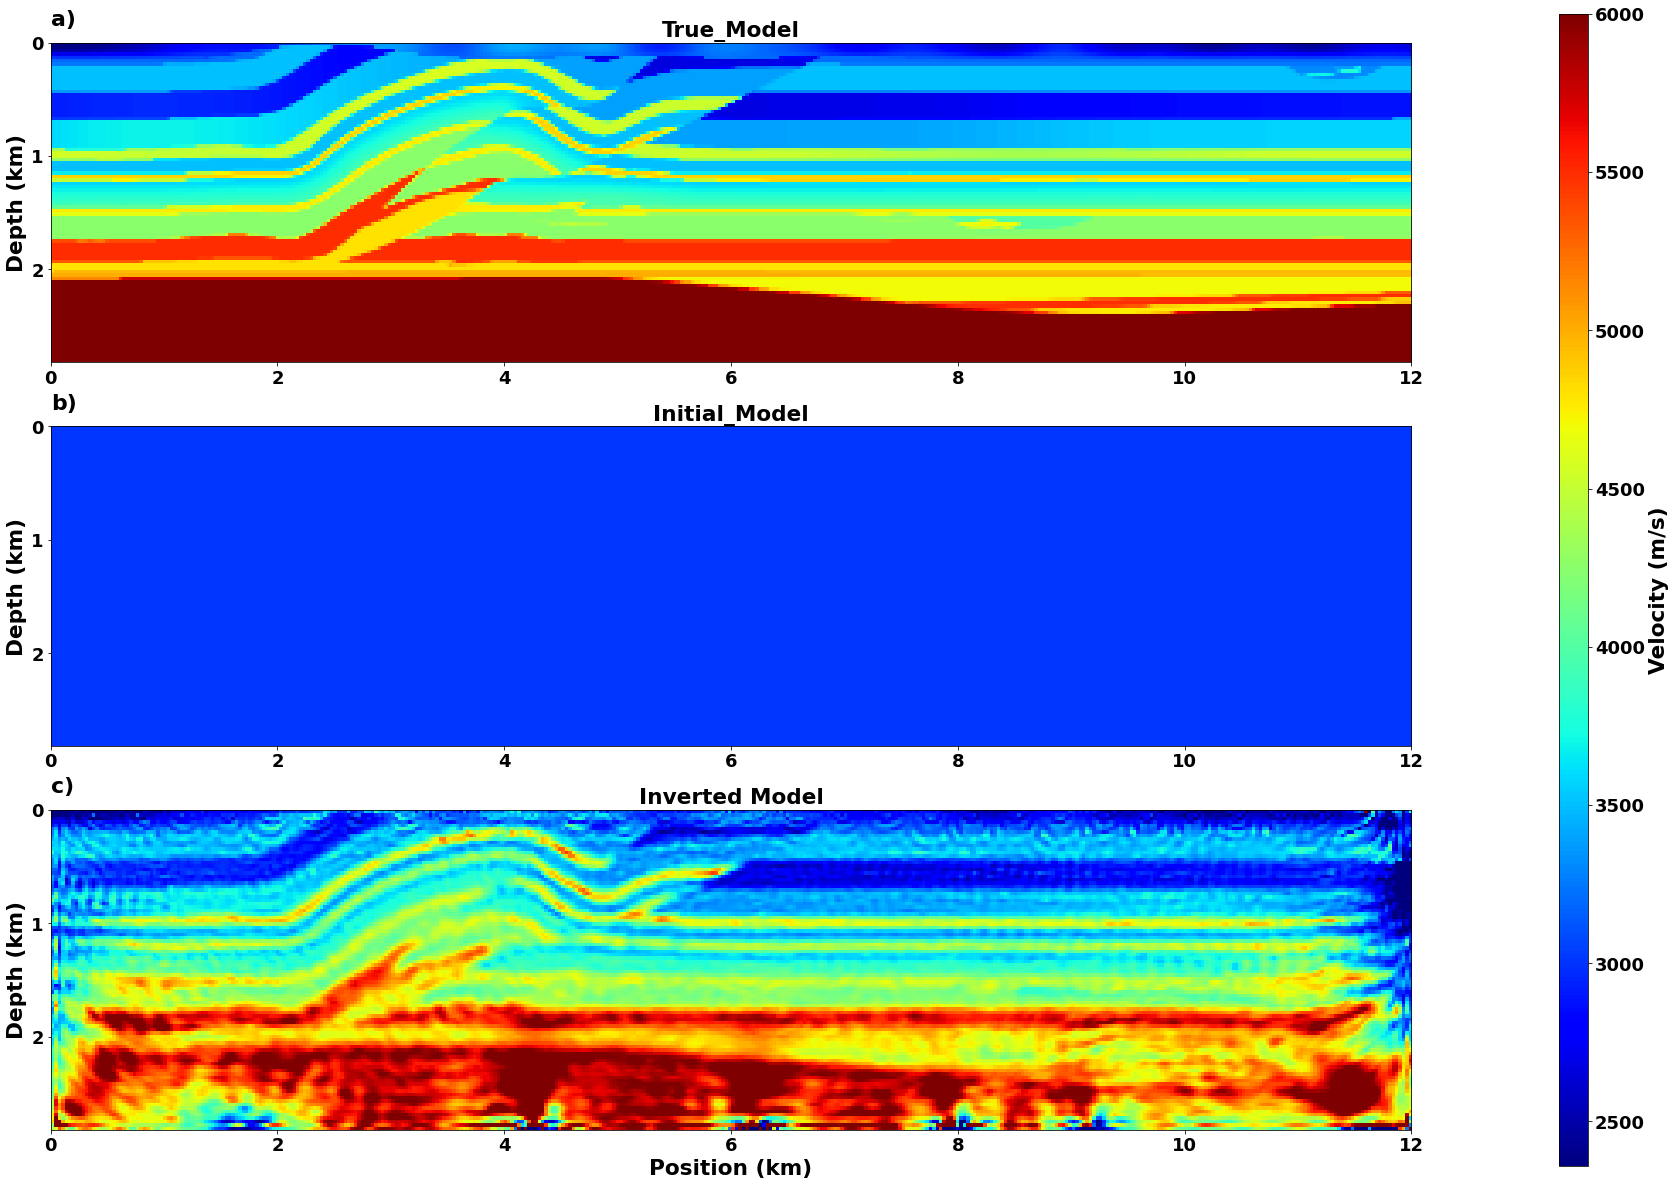

The reconstructed velocity model has SNR: 18.035174297379143 dB and SSIM: 0.591758


In [9]:
f, ax = plt.subplots(3,1,figsize=(40, 20))
plt.rc('font', **font)

# True Model
modeltrue = model1
im = ax[0].imshow(modeltrue, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, modeltrue.shape[1] * dx / 1000, modeltrue.shape[0] * dx / 1000, 0])

#ax[0].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[0].set_title('True_Model',fontsize='large', fontweight='bold')
ax[0].text(0, -0.15, 'a)', fontsize = 22) 
ax[0].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[0].set_yticks(np.arange(y.min(), y.max(), 1)) 

# Initial Model
init_V = model_init
im = ax[1].imshow(init_V, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, init_V.shape[1] * dx / 1000, init_V.shape[0] * dx / 1000, 0])
#ax[1].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[1].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[1].set_title('Initial_Model',fontsize='large', fontweight='bold')
ax[1].text(0, -0.15, 'b)', fontsize = 22) 
ax[1].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[1].set_yticks(np.arange(y.min(), y.max(), 1)) 

# Siamese Model
Siamese_Vel = scipy.io.loadmat(fwi_result + 'SIAMESERec_399.mat')
Siamese_Vel = Siamese_Vel['rec']
im = ax[2].imshow(Siamese_Vel, cmap='jet', vmin=box_min, vmax=box_max, 
                extent=[0, Siamese_Vel.shape[1] * dx / 1000, Siamese_Vel.shape[0] * dx / 1000, 0])
ax[2].set_xlabel('Position (km)',fontsize='large', fontweight='bold')
ax[2].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[2].set_title('Inverted Model',fontsize='large', fontweight='bold')
ax[2].text(0, -0.15, 'c)', fontsize = 22) 
ax[2].xaxis.set_major_locator(MaxNLocator(integer=True))
ax[2].set_yticks(np.arange(y.min(), y.max(), 1)) 


cbar_ax = f.add_axes([0.8, 0.1, 0.01, 0.8])
f.colorbar(im, fraction=0.005, pad=0.04,cax=cbar_ax)
cbar_ax.set_ylabel('Velocity (m/s)',fontsize='large', fontweight='bold')

plt.show()

snr = ComputeSNR(Siamese_Vel,  
          model_true.detach().cpu().numpy())

ssim = ComputeSSIM(Siamese_Vel, \
          model_true.detach().cpu().numpy())

print('The reconstructed velocity model has SNR:', str(snr), 'dB', 'and SSIM:',str(ssim.cpu().detach().cpu().numpy()))

## Plotting Velocities Profiles

@Position =  1.2 km, RMSE =  0.7245442240336792 km/s
@Position =  3.6 km, RMSE =  0.4187420616536172 km/s
@Position =  7.2 km, RMSE =  0.20918415004269236 km/s


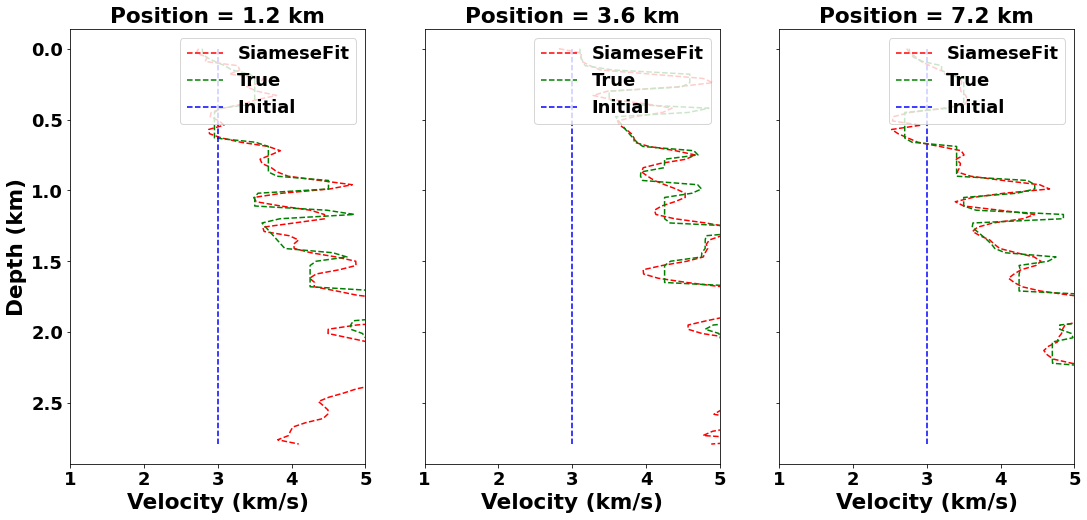

In [10]:
from math import sqrt

# position 1
k = 40

xy = np.arange(0,Siamese_Vel.shape[0] * dx / 1000, len(Siamese_Vel[:,k])/Siamese_Vel.shape[0] * dx / 1000)
f, ax = plt.subplots(figsize=(18, 8), ncols=3,nrows=1)
xx = np.arange(0,8)
ax[0].plot(Siamese_Vel[:,k]/1000,xy,'r--',label='SiameseFit')
ax[0].plot(modeltrue[:,k]/1000,xy,'g--',label='True')
ax[0].plot(init_V[:,k]/1000,xy,'b--',label='Initial')
ax[0].set_ylabel('Depth (km)',fontsize='large', fontweight='bold')
ax[0].set_xlabel('Velocity (km/s)',fontsize='large', fontweight='bold')
ax[0].set_xlim([1,5])
ax[0].legend(loc='upper right')
ax[0].set_title( 'Position = ' + str(k * dx / 1000) +' km',fontsize='large', fontweight='bold')
ax[0].invert_yaxis()
rms = sqrt(np.mean(((modeltrue[:,k]-Siamese_Vel[:,k])/1000)**2))
print('@Position = ', str(k * dx / 1000), 'km, RMSE = ',str(rms), 'km/s')

# position 2
k = 120
xy = np.arange(0,Siamese_Vel.shape[0] * dx / 1000, len(Siamese_Vel[:,k])/Siamese_Vel.shape[0] * dx / 1000)
xx = np.arange(0,8)
ax[1].plot(Siamese_Vel[:,k]/1000,xy,'r--',label='SiameseFit')
ax[1].plot(modeltrue[:,k]/1000,xy,'g--',label='True')
ax[1].plot(init_V[:,k]/1000,xy,'b--',label='Initial')
ax[1].set_xlabel('Velocity (km/s)',fontsize='large', fontweight='bold')
ax[1].set_yticklabels([])
ax[1].set_xlim([1,5])
ax[1].legend(loc='upper right')
ax[1].set_title( 'Position = ' + str(k * dx / 1000) +' km',fontsize='large', fontweight='bold')
ax[1].invert_yaxis()
rms = sqrt(np.mean(((modeltrue[:,k]-Siamese_Vel[:,k])/1000)**2))
print('@Position = ', str(k * dx / 1000), 'km, RMSE = ',str(rms), 'km/s')

# position 3
k = 240
xy = np.arange(0,Siamese_Vel.shape[0] * dx / 1000, len(Siamese_Vel[:,k])/Siamese_Vel.shape[0] * dx / 1000)
xx = np.arange(0,8)
ax[2].plot(Siamese_Vel[:,k]/1000,xy,'r--',label='SiameseFit')
ax[2].plot(modeltrue[:,k]/1000,xy,'g--',label='True')
#ax[2].plot(FWIGAN_Vel[:,k]/1000,xy,'y--',label='FWIGAN')
ax[2].plot(init_V[:,k]/1000,xy,'b--',label='Initial')
ax[2].set_xlabel('Velocity (km/s)',fontsize='large', fontweight='bold')
ax[2].set_yticklabels([])
ax[2].set_xlim([1,5])
#ax[2].ylim([0,3.8])
ax[2].legend(loc='upper right')
ax[2].set_title( 'Position = ' + str(k * dx / 1000) +' km',fontsize='large', fontweight='bold')
ax[2].invert_yaxis()
rms = sqrt(np.mean(((modeltrue[:,k]-Siamese_Vel[:,k])/1000)**2))
print('@Position = ', str(k * dx / 1000), 'km, RMSE = ',str(rms), 'km/s')



In [11]:
torch.save(netD.state_dict(), fwi_result + 'netD')